In [1]:
!pip install kagglehub

In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "gunavenkatdoddi/eye-diseases-classification"
)

DATASET_PATH = path
print("Path:", DATASET_PATH)

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Path: /kaggle/input/eye-diseases-classification


In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_CLASSES = 4

In [5]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return enhanced

In [6]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = apply_clahe(img)

    img = preprocess_input(img)

    return img

In [7]:
class RetinalDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size=8, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_x = self.image_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_y = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X, y = [], []

        for path, label in zip(batch_x, batch_y):
            img = preprocess_image(path)

            if self.augment:
                if np.random.rand() > 0.5:
                    img = np.fliplr(img)
                if np.random.rand() > 0.5:
                    img = np.flipud(img)

            X.append(img)
            y.append(label)

        return np.array(X), np.array(y)

In [8]:
class_names = [
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "normal"
]

label_map = {cls: idx for idx, cls in enumerate(class_names)}

image_paths = []
labels = []

for cls in class_names:
    folder = os.path.join(DATASET_PATH, "dataset", cls)
    print("Reading:", folder)

    for img in os.listdir(folder):
        image_paths.append(os.path.join(folder, img))
        labels.append(label_map[cls])

labels = np.array(labels)

Reading: /kaggle/input/eye-diseases-classification/dataset/cataract
Reading: /kaggle/input/eye-diseases-classification/dataset/diabetic_retinopathy
Reading: /kaggle/input/eye-diseases-classification/dataset/glaucoma
Reading: /kaggle/input/eye-diseases-classification/dataset/normal


In [9]:
train_p, temp_p, train_l, temp_l = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

val_p, test_p, val_l, test_l = train_test_split(
    temp_p,
    temp_l,
    test_size=0.5,
    random_state=42,
    stratify=temp_l
)

train_l = to_categorical(train_l, NUM_CLASSES)
val_l = to_categorical(val_l, NUM_CLASSES)
test_l = to_categorical(test_l, NUM_CLASSES)

In [10]:
train_gen = RetinalDataGenerator(train_p, train_l, BATCH_SIZE, augment=True)
val_gen   = RetinalDataGenerator(val_p, val_l, BATCH_SIZE)
test_gen  = RetinalDataGenerator(test_p, test_l, BATCH_SIZE)

In [11]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Unfreeze last layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 904,836 (3.45 MB)

 Non-trainable params: 6,396,096 (24.40 MB)

In [12]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 107s 188ms/step - accuracy: 0.6923 - loss: 0.7793 - val_accuracy: 0.8813 - val_loss: 0.3634
Epoch 2/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 35s 96ms/step - accuracy: 0.8302 - loss: 0.4619 - val_accuracy: 0.8940 - val_loss: 0.2767
Epoch 3/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.8713 - loss: 0.3626 - val_accuracy: 0.9098 - val_loss: 0.2279
Epoch 4/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.8916 - loss: 0.3011 - val_accuracy: 0.9177 - val_loss: 0.1987
Epoch 5/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 35s 96ms/step - accuracy: 0.9015 - loss: 0.2691 - val_accuracy: 0.9225 - val_loss: 0.1917
Epoch 6/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.9243 - loss: 0.2023 - val_accuracy: 0.9193 - val_loss: 0.1924
Epoch 7/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.9409 - loss: 0.1794 - val_accuracy: 0.9256 - val_loss: 0.1907
Epoch 8/15
368/368 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.9484 - loss: 0.1434 

In [15]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.9335 - loss: 0.2294
Test Accuracy: 0.9335442781448364


79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step


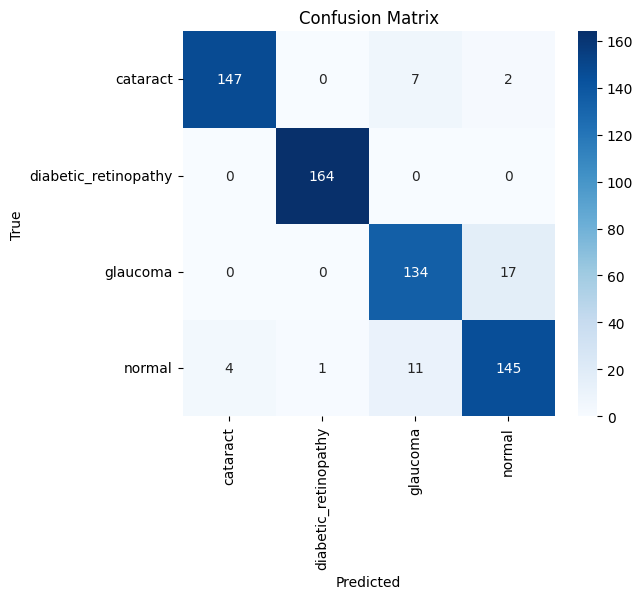

                      precision    recall  f1-score   support

            cataract     0.9735    0.9423    0.9577       156
diabetic_retinopathy     0.9939    1.0000    0.9970       164
            glaucoma     0.8816    0.8874    0.8845       151
              normal     0.8841    0.9006    0.8923       161

            accuracy                         0.9335       632
           macro avg     0.9333    0.9326    0.9329       632
        weighted avg     0.9341    0.9335    0.9337       632



In [16]:
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true_full = np.argmax(test_l, axis=1)
y_true = y_true_full[:len(y_pred)]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)